<a href="https://colab.research.google.com/github/kevinl03/stochastic-spread-modeling/blob/data-analysis-incl-jul-19-22/statarb/cex_gbm_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# StatArb LightGBM Pipeline
Cross-exchange spread z-score prediction across all coins × exchange pairs.

**Target:** z-score of `spread_pct` at `t+5` snapshots, rolling-normalised over 60 snapshots  
**Features:** lag-1..5 of spread, ticker mid/BA, orderbook imbalance, trade flow, funding rate, OI  
**Model:** single LightGBM; `coin` and `pair` as native categoricals

## 1. Imports & Config

In [1]:
import json
import warnings
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import gc

from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

assert HF_TOKEN is not None, "HF_TOKEN not found — check your .env file"
print("Token loaded:", HF_TOKEN[:8], "...")  # prints first 8 chars only, safe to display

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# ── paths — adjust if your layout differs ────────────────────────────────────
DATA_ROOT  = Path("./cex_dat")  # unused if USE_HF = True
USE_HF     = True               # ← add this
HF_REPO    = "SFU-fintech-AI/statarb-crypto-research"

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── model / feature config ────────────────────────────────────────────────────
HORIZON       = 1    # snapshots ahead to predict (default was 5 min)
ZSCORE_WINDOW = 300   # rolling window for z-score normalisation (default was 60 min)
N_LAGS        = 3    # lag depth for every feature group (default was 5)
MIN_PERIODS   = 60   # min observations before z-score is emitted (default 20)

LGBM_PARAMS = {
    "objective":         "regression", #"regression" or "binary"
    "metric":            ["rmse", "mae"],
    "learning_rate":     0.075, #0.05
    "num_leaves":        255, #127
    "min_child_samples": 150, #50
    "feature_fraction":  0.6, #0.7
    "bagging_fraction":  0.7, #0.8
    "bagging_freq":      5, #5
    "lambda_l1":         0.1, #0.1
    "lambda_l2":         0.1, #0.1
    "verbosity":         -1, #-1
    "n_jobs":            -1, #-1
    "seed":              42, #42
}
NUM_BOOST_ROUND = 2500 #1000
EARLY_STOPPING  = 250 #50

Token loaded: hf_nubaY ...


In [2]:
# only keep payloads for these — set to False to skip a table entirely
LOAD_TABLES = {
    "spread_matrix": True,
    "ticker":        True,
    "orderbook":     True,
    "trades":        True,
    "funding_rate":  True,  # toggle off to save RAM if still crashing
    "open_interest": True,  # toggle off to save RAM if still crashing
    "ohlcv":         False,  # toggle off to skip OHLCV features entirely
}

TOP_EXCHANGES = ["binance", "bybit", "okx", "coinbase", "kraken", "mexc"]  # drop smaller venues
TOP_FEATURES  = {
    "ticker":    ["mid", "spread_bps", "bid_volume", "ask_volume"],  # drop vwap, pct_change_24h
    "orderbook": ["imbalance", "slippage_bps"],                      # drop depth/vwap cols
    "trades":    ["buy_sell_ratio", "total_volume"],                  # drop count, price_mean
    "funding":   ["funding_rate"],                                    # drop next_rate, mark_price
    "oi":        ["oi_amount"],                                       # drop oi_value (mostly null)
}

## 2. Data Loading
Drops error rows (`error IS NOT NULL`) on load — these are failed ccxt fetches, not missing data.

In [3]:
SUBSETS = ["spread_matrix", "ticker", "orderbook", "trades", "funding_rate", "open_interest", "ohlcv"]

# ── Window definitions ────────────────────────────────────────────────────────
# Each entry is one contiguous collection run.  Windows with multiple contiguous
# parts (pre/post outage) are listed as separate sub-entries so lags never
# silently bridge a gap.  snapshot_idx is LOCAL to each window — do not compare
# across windows.
#
# role → how this window is used:
#   "train"  : pooled into training data
#   "test"   : held-out final evaluation (Jul 19-22)
#
# hf_prefix  : HuggingFace config-name prefix for the 8 signal subsets
# hf_ohlcv   : HuggingFace config name for the OHLCV subset (schema varies)
# ohlcv_schema: "flat"     → train-style ohlcv with columns already flat
#               "snapshot" → Jul19-22 ohlcv_snapshot with unified payload schema

WINDOWS = [
    # ── Training pool ─────────────────────────────────────────────────────────
    {
        "id":           "jun13",
        "role":         "train",
        "label":        "Jun 13-16",
        "hf_prefix":    "",          # root-level configs have no prefix
        "hf_split": "train",
        "hf_ohlcv":     "ohlcv",
        "ohlcv_schema": "flat",
    },
    {
        "id":           "jun22",
        "role":         "train",
        "label":        "Jun 22-24",
        "hf_prefix":    "test_",     # originally named "test" on HF
        "hf_split": "train",
        "hf_ohlcv":     "test_ohlcv_live",
        "ohlcv_schema": "flat",
    },
    {
        "id":           "jul13",
        "role":         "train",
        "label":        "Jul 13-15 (partial)",
        "hf_prefix":    "validation_",
        "hf_split": "train",
        "hf_ohlcv":     None,
        "ohlcv_schema": "flat",
    },
    # ── Test pool (Jul 19-22, split around power-loss outage) ─────────────────
    {
        "id":           "jul19_pre",
        "role":         "test",
        "label":        "Jul 19-22 pre-outage",
        "hf_prefix":    "jul19_22_pre_outage_",
        "hf_split":     "train",
        "hf_ohlcv":     "jul19_22_pre_outage_ohlcv_snapshot",
        "ohlcv_schema": "snapshot",
    },
    {
        "id":           "jul19_post",
        "role":         "test",
        "label":        "Jul 19-22 post-outage",
        "hf_prefix":    "jul19_22_post_outage_",
        "hf_split":     "train",
        "hf_ohlcv":     "jul19_22_post_outage_ohlcv_snapshot",
        "ohlcv_schema": "snapshot",
    },
]

# ── HF subset name resolver ───────────────────────────────────────────────────
# Maps local table name → HF config name for a given window.
# The 8 signal tables follow a consistent prefix pattern.
# OHLCV is handled separately because its HF name and schema differ per window.
_SIGNAL_TABLES = ["spread_matrix", "ticker", "orderbook", "trades",
                  "funding_rate", "open_interest"]

def hf_name_for(window: dict, local_name: str) -> str:
    prefix = window["hf_prefix"]
    return f"{prefix}{local_name}"

# ── OHLCV column normalisation ────────────────────────────────────────────────
# "flat" schema  (train/test/val ohlcv files): columns are already top-level.
#   run_id, exchange, coin, symbol, timestamp, datetime, open, high, low, close,
#   volume, [source, fetched_at]
#
# "snapshot" schema (ohlcv_snapshot.parquet in Jul19-22): uses the unified
#   signal schema with a `payload` JSON column containing the OHLCV fields.
#   run_id, ts, snapshot_idx, exchange, coin, market, symbol, error, payload
#
# Both are normalised to:
#   snapshot_idx, coin, exchange, ohlcv_open, ohlcv_high, ohlcv_low,
#   ohlcv_close, ohlcv_volume

def _normalise_ohlcv_flat(df: pd.DataFrame) -> pd.DataFrame:
    """Flat schema: columns already exist, no payload to parse."""
    rename = {
        "open":   "ohlcv_open",
        "high":   "ohlcv_high",
        "low":    "ohlcv_low",
        "close":  "ohlcv_close",
        "volume": "ohlcv_volume",
    }
    df = df.rename(columns=rename)
    keep = ["snapshot_idx", "coin", "exchange",
            "ohlcv_open", "ohlcv_high", "ohlcv_low", "ohlcv_close", "ohlcv_volume"]
    # snapshot_idx may be absent in backfilled flat files — derive from row order
    # grouped by (coin, exchange) if missing
    if "snapshot_idx" not in df.columns:
        df = df.sort_values(["exchange", "coin", "timestamp"] if "timestamp" in df.columns
                            else ["exchange", "coin"])
        df["snapshot_idx"] = df.groupby(["coin", "exchange"]).cumcount() + 1
    return df[[c for c in keep if c in df.columns]].copy()


def _normalise_ohlcv_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """Snapshot schema: parse payload JSON to extract OHLCV fields."""
    records = []
    for row in df.itertuples():
        try:
            p = json.loads(row.payload) if isinstance(row.payload, str) else row.payload
            records.append((
                row.snapshot_idx,
                row.coin,
                row.exchange,
                float(p.get("open")   or 0),
                float(p.get("high")   or 0),
                float(p.get("low")    or 0),
                float(p.get("close")  or 0),
                float(p.get("volume") or 0),
            ))
        except Exception:
            continue
    return pd.DataFrame(records, columns=[
        "snapshot_idx", "coin", "exchange",
        "ohlcv_open", "ohlcv_high", "ohlcv_low", "ohlcv_close", "ohlcv_volume",
    ])


# ── Core loader ───────────────────────────────────────────────────────────────

def _load_one_window(window: dict) -> dict[str, pd.DataFrame]:
    """Load all enabled tables for a single contiguous window.

    Returns the same dict[str, pd.DataFrame] shape the rest of the pipeline
    expects, with an added 'window_id' string column on every frame so lags
    can be grouped per-window and never bridge the inter-window gap.
    """
    from datasets import load_dataset
    result = {}
    wid = window["id"]

    for local_name in SUBSETS:
        if not LOAD_TABLES.get(local_name, True):
            print(f"    [skip] {local_name}")
            result[local_name] = pd.DataFrame()
            continue

        hf = hf_name_for(window, local_name)
        print(f"    loading {hf} …", end=" ")
        try:
            ds = load_dataset(HF_REPO, hf, split="train", token=HF_TOKEN)
        except Exception as e:
            print(f"[WARN: {e}]")
            result[local_name] = pd.DataFrame()
            continue

        # drop columns we never need before materialising to pandas
        drop = [c for c in ["run_id", "ts", "market", "symbol", "error"]
                if c in ds.column_names]
        if drop:
            ds = ds.remove_columns(drop)
        df = ds.to_pandas()
        del ds
        gc.collect()

        # ── OHLCV: normalise schema, then skip the shared payload parser ──
        if local_name == "ohlcv":
            if window["ohlcv_schema"] == "snapshot":
                out = _normalise_ohlcv_snapshot(df)
            else:
                out = _normalise_ohlcv_flat(df)
            del df
            gc.collect()
            # cast numerics
            for col in ["ohlcv_open","ohlcv_high","ohlcv_low","ohlcv_close","ohlcv_volume"]:
                if col in out.columns:
                    out[col] = out[col].astype("float32")
            if "snapshot_idx" in out.columns:
                out["snapshot_idx"] = out["snapshot_idx"].astype("int32")
            out["window_id"] = wid
            result[local_name] = out
            print(out.shape, f"  mem: {out.memory_usage(deep=True).sum()/1e6:.1f} MB")
            del out
            gc.collect()
            continue

        # ── Signal tables: shared payload parser (unchanged logic) ────────
        records = []
        for row in df.itertuples():
            try:
                p    = json.loads(row.payload) if isinstance(row.payload, str) else row.payload
                snap = row.snapshot_idx
                coin = row.coin
                exch = getattr(row, "exchange", None)

                if local_name == "spread_matrix":
                    for pair in p["pairwise_spreads"]:
                        if pair["ex1"] in TOP_EXCHANGES and pair["ex2"] in TOP_EXCHANGES:
                            records.append((snap, coin, pair["ex1"], pair["ex2"],
                                            float(pair["spread_bps"]),
                                            float(pair["p1"]), float(pair["p2"])))
                elif local_name == "ticker" and exch in TOP_EXCHANGES:
                    records.append((snap, coin, exch,
                                    float(p.get("mid") or 0),
                                    float(p.get("spread_bps") or 0),
                                    float(p.get("bid_volume") or 0),
                                    float(p.get("ask_volume") or 0)))
                elif local_name == "orderbook" and exch in TOP_EXCHANGES:
                    records.append((snap, coin, exch,
                                    float(p.get("imbalance") or 0),
                                    float(p.get("slippage_bps") or 0)))
                elif local_name == "trades" and exch in TOP_EXCHANGES:
                    records.append((snap, coin, exch,
                                    float(p.get("buy_sell_ratio") or 0),
                                    float(p.get("total_volume") or 0)))
                elif local_name == "funding_rate" and exch in TOP_EXCHANGES:
                    records.append((snap, coin, exch,
                                    float(p.get("funding_rate") or 0)))
                elif local_name == "open_interest" and exch in TOP_EXCHANGES:
                    records.append((snap, coin, exch,
                                    float(p.get("open_interest_amount") or 0)))
            except Exception:
                continue

        del df
        gc.collect()

        COLS = {
            "spread_matrix": ["snapshot_idx","coin","exchange_a","exchange_b","spread_bps","p1","p2"],
            "ticker":        ["snapshot_idx","coin","exchange","mid","spread_bps","bid_volume","ask_volume"],
            "orderbook":     ["snapshot_idx","coin","exchange","imbalance","slippage_bps"],
            "trades":        ["snapshot_idx","coin","exchange","buy_sell_ratio","total_volume"],
            "funding_rate":  ["snapshot_idx","coin","exchange","funding_rate"],
            "open_interest": ["snapshot_idx","coin","exchange","oi_amount"],
        }
        out = pd.DataFrame(records, columns=COLS[local_name])
        out["window_id"] = wid

        num_cols = out.select_dtypes(include="float64").columns
        out[num_cols] = out[num_cols].astype("float32")
        int_cols = out.select_dtypes(include="int64").columns
        out[int_cols] = out[int_cols].astype("int32")

        result[local_name] = out
        print(out.shape, f"  mem: {out.memory_usage(deep=True).sum()/1e6:.1f} MB")
        del records, out
        gc.collect()

    return result


def _pool_windows(windows: list[dict]) -> dict[str, pd.DataFrame]:
    """Load multiple windows and concatenate them table-by-table.

    Each window is kept as an independent sequence via 'window_id'.
    The downstream lag/z-score functions must group by window_id in addition
    to (coin, pair/exchange) so lags never bridge the inter-window gap.
    """
    accumulated: dict[str, list[pd.DataFrame]] = {s: [] for s in SUBSETS}
    for w in windows:
        print(f"\n  ── {w['label']} ({w['id']}) ──")
        window_data = _load_one_window(w)
        for table, df in window_data.items():
            if not df.empty:
                accumulated[table].append(df)

    pooled = {}
    for table, frames in accumulated.items():
        if frames:
            pooled[table] = pd.concat(frames, ignore_index=True)
            print(f"  pooled {table:20s} → {len(pooled[table]):>10,} rows")
        else:
            pooled[table] = pd.DataFrame()
    return pooled


# ── Build train and test sets ─────────────────────────────────────────────────
train_windows = [w for w in WINDOWS if w["role"] == "train"]
test_windows  = [w for w in WINDOWS if w["role"] == "test"]

print("=" * 60)
print("Loading TRAIN pool (Jun 13-16 + Jun 22-24 + Jul 13-15) …")
print("=" * 60)
train_raw = _pool_windows(train_windows)

print("\n" + "=" * 60)
print("Loading TEST pool (Jul 19-22 pre + post outage) …")
print("=" * 60)
test_raw = _pool_windows(test_windows)

# val_raw kept as empty dict for backward compatibility with eval cell
val_raw = {s: pd.DataFrame() for s in SUBSETS}

print("\nDone. Final table sizes:")
for table in SUBSETS:
    tr = len(train_raw.get(table, []))
    te = len(test_raw.get(table,  []))
    print(f"  {table:20s}  train={tr:>10,}  test={te:>10,}")


Loading TRAIN pool (Jun 13-16 + Jun 22-24 + Jul 13-15) …

  ── Jun 13-16 (jun13) ──
    loading spread_matrix … (1348050, 8)   mem: 311.8 MB
    loading ticker … (539337, 8)   mem: 97.5 MB
    loading orderbook … (7823, 6)   mem: 1.3 MB
    loading trades … (539376, 6)   mem: 93.2 MB
    loading funding_rate … (32452, 5)   mem: 4.5 MB
    loading open_interest … (23851, 5)   mem: 3.3 MB
    [skip] ohlcv

  ── Jun 22-24 (jun22) ──
    loading test_spread_matrix … (1189155, 8)   mem: 275.1 MB
    loading test_ticker … (476406, 8)   mem: 86.1 MB
    loading test_orderbook … (6948, 6)   mem: 1.2 MB
    loading test_trades … (476681, 6)   mem: 82.4 MB
    loading test_funding_rate … (28717, 5)   mem: 4.0 MB
    loading test_open_interest … (21106, 5)   mem: 3.0 MB
    [skip] ohlcv

  ── Jul 13-15 (partial) (jul13) ──
    loading validation_spread_matrix … (476013, 8)   mem: 110.1 MB
    loading validation_ticker … (191328, 8)   mem: 34.6 MB
    loading validation_orderbook … (3017, 6)   mem

## 3. Feature Engineering — Spread Matrix
This is the backbone. Every other feature table joins onto the `(snapshot_idx, coin, pair)` grain produced here.

- Parses `payload` JSON if columns aren't already flat
- Derives `spread_pct` from whatever price columns are present
- Computes rolling z-score **and** shifts it forward by `HORIZON` to form the target
- Adds lag-1..N of both `spread_pct` and `zscore`

In [4]:
def build_spread_features(sm: pd.DataFrame) -> pd.DataFrame:
    if sm.empty:
        return pd.DataFrame()

    sm = sm.copy()
    sm["pair"] = sm["exchange_a"] + "__" + sm["exchange_b"]
    sm = sm.sort_values(["window_id", "coin", "pair", "snapshot_idx"]).reset_index(drop=True)

    grp_keys = ["window_id", "coin", "pair"]
    grp = sm.groupby(grp_keys)["spread_bps"]

    roll_mean = grp.transform(lambda x: x.rolling(ZSCORE_WINDOW, min_periods=MIN_PERIODS).mean())
    roll_std  = grp.transform(lambda x: x.rolling(ZSCORE_WINDOW, min_periods=MIN_PERIODS).std())
    sm["zscore"] = (sm["spread_bps"] - roll_mean) / roll_std.replace(0, np.nan)
    del roll_mean, roll_std

    # OPTION 1
    sm["target"] = sm.groupby(grp_keys)["zscore"].transform(lambda x: x.shift(-HORIZON))

    # OPTION 2 - spread lambda
    #sm["target"] = sm.groupby(grp_keys)["spread_bps"].transform(lambda x: x.shift(-HORIZON) - x)

    # OPTION 3 - signed reversion
    #sm["target"] = sm.groupby(grp_keys)["zscore"].transform(lambda x: x - x.shift(-HORIZON))

    # OPTION 4 - binary classification
    #sm["target"] = (sm.groupby(grp_keys)["zscore"].transform(lambda x: x - x.shift(-HORIZON)) > 0.5).astype(int)

    for lag in range(1, N_LAGS + 1):
        sm[f"spread_bps_lag{lag}"] = grp.transform(lambda x, l=lag: x.shift(l))
        sm[f"zscore_lag{lag}"]     = sm.groupby(grp_keys)["zscore"].transform(lambda x, l=lag: x.shift(l))

    # drop raw cols no longer needed; keep only feature + key cols
    sm = sm.drop(columns=["exchange_a", "exchange_b", "p1", "p2"], errors="ignore")
    return sm


## 4. Feature Engineering — Ticker
Derives mid-price and bid-ask spread (%), lags both, then pivots wide so each exchange becomes its own column set.

In [5]:
def _to_wide(df, index_cols, col_col, value_cols, prefix):
    """Compute lags and pivot long→wide without pivot_table.

    Strategy:
    1. Compute lag columns in-place on the long frame.
    2. Keep only the columns needed for unstack.
    3. set_index + unstack (much leaner than pivot_table).
    4. Flatten MultiIndex columns.
    5. Return wide frame; caller frees long frame immediately.
    """
    df = df.sort_values(index_cols + [col_col]).reset_index(drop=True)

    lag_cols = []
    grp = df.groupby(["window_id", "coin", col_col])
    for col in value_cols:
        for lag in range(1, N_LAGS + 1):
            name = f"{col}_lag{lag}"
            df[name] = grp[col].transform(lambda x, l=lag: x.shift(l))
            lag_cols.append(name)

    # drop raw value cols — we only need the lags now
    df = df.drop(columns=value_cols, errors="ignore")

    # cast to float32 before unstack to halve memory of the wide frame
    df[lag_cols] = df[lag_cols].astype("float32")

    keep = index_cols + [col_col] + lag_cols
    df = df[keep].copy()

    wide = (
        df.groupby(index_cols + [col_col])[lag_cols]
          .mean()
          .unstack(col_col)
    )
    del df
    gc.collect()

    wide.columns = [f"{prefix}{col}_{exch}" for col, exch in wide.columns]
    wide.columns.name = None
    return wide.reset_index()

def build_ticker_features(tk: pd.DataFrame) -> pd.DataFrame:
    if tk.empty: return pd.DataFrame()
    out = _to_wide(tk, ["snapshot_idx", "coin", "window_id"], "exchange",
                   ["mid", "spread_bps", "bid_volume", "ask_volume"], "tk_")
    print("ticker works")
    return out



## 5. Feature Engineering — Orderbook
Computes top-5-level order book imbalance: `(bid_vol - ask_vol) / (bid_vol + ask_vol)`.  
Parses nested `bids`/`asks` lists from payload if volume columns aren't already present.

In [6]:
def build_orderbook_features(ob: pd.DataFrame) -> pd.DataFrame:
    if ob.empty: return pd.DataFrame()
    out = _to_wide(ob, ["snapshot_idx", "coin", "window_id"], "exchange",
                   ["imbalance", "slippage_bps"], "ob_")
    print("orderbook works")
    return out


## 6. Feature Engineering — Trades
Net signed flow per snapshot: `sum(buy_vol) - sum(sell_vol)`.  
If `side` is missing, falls back to unsigned total volume.

In [7]:
def build_trades_features(tr: pd.DataFrame) -> pd.DataFrame:
    if tr.empty: return pd.DataFrame()
    out = _to_wide(tr, ["snapshot_idx", "coin", "window_id"], "exchange",
                   ["buy_sell_ratio", "total_volume"], "tr_")
    print("trades works")
    return out



## 7. Feature Engineering — Funding Rate & Open Interest
Both are perp-only signals (NaN for spot venues). LightGBM handles NaN natively so no imputation needed.

In [8]:
def build_funding_features(fr: pd.DataFrame) -> pd.DataFrame:
    if fr.empty: return pd.DataFrame()
    out = _to_wide(fr, ["snapshot_idx", "coin", "window_id"], "exchange",
                   ["funding_rate"], "fr_")
    print("funding rate works")
    return out


def build_oi_features(oi: pd.DataFrame) -> pd.DataFrame:
    if oi.empty: return pd.DataFrame()
    out = _to_wide(oi, ["snapshot_idx", "coin", "window_id"], "exchange",
                   ["oi_amount"], "oi_")
    print("oi works")
    return out


def build_ohlcv_features(ohlcv: pd.DataFrame) -> pd.DataFrame:
    if ohlcv.empty: return pd.DataFrame()
    feat_cols = [c for c in ["ohlcv_open","ohlcv_high","ohlcv_low","ohlcv_close","ohlcv_volume"]
                 if c in ohlcv.columns]
    out = _to_wide(ohlcv, ["snapshot_idx", "coin", "window_id"], "exchange",
                   feat_cols, "ohlcv_")
    print("ohlcv works")
    return out



## 8. Merge All Features
Left-join everything onto the spread base frame on `(snapshot_idx, coin)`.  
Missing auxiliary rows become NaN — handled by LightGBM natively.

In [9]:
def build_feature_matrix(raw: dict[str, pd.DataFrame]) -> pd.DataFrame:
    print("  spread …", end=" ")
    base = build_spread_features(raw.pop("spread_matrix", pd.DataFrame()))
    gc.collect()
    if base.empty:
        raise ValueError("spread_matrix empty or unparseable")
    print(base.shape)

    builders = [
        ("ticker",   build_ticker_features,   "ticker"),
        ("orderbook",build_orderbook_features, "orderbook"),
        ("trades",   build_trades_features,    "trades"),
        ("funding",  build_funding_features,   "funding_rate"),
        ("OI",       build_oi_features,        "open_interest"),
        ("ohlcv",    build_ohlcv_features,     "ohlcv"),
    ]

    merge_keys = ["window_id", "snapshot_idx", "coin"]
    df = base
    del base
    gc.collect()

    for label, fn, raw_key in builders:
        data = raw.pop(raw_key, pd.DataFrame())
        aux  = fn(data)
        del data
        gc.collect()

        if aux is not None and not aux.empty:
            # use pd.merge with copy=False to avoid duplicating df
            df = pd.merge(df, aux, on=merge_keys, how="left", copy=False)
            del aux
            gc.collect()
            print(f"  + {label:10s} → {df.shape}  mem: {df.memory_usage(deep=True).sum()/1e6:.0f} MB")

    df = df.drop(columns=["window_id"], errors="ignore")

    # downcast remaining float64 columns that crept in via merge
    f64 = df.select_dtypes("float64").columns
    if len(f64):
        df[f64] = df[f64].astype("float32")
        gc.collect()

    return df


print("Building train …")
df_train = build_feature_matrix(train_raw)
gc.collect()
print(f"train: {df_train.shape}  mem: {df_train.memory_usage(deep=True).sum()/1e6:.0f} MB")

print("\nBuilding test …")
df_test = build_feature_matrix(test_raw)
gc.collect()
print(f"test:  {df_test.shape}  mem: {df_test.memory_usage(deep=True).sum()/1e6:.0f} MB")

#print("\nBuilding val …")
#df_val = build_feature_matrix(val_raw)
df_val = pd.DataFrame([])

#gc.collect()

Building train …
  spread … (3013218, 13)
ticker works
  + ticker     → (3013218, 85)  mem: 1556 MB
orderbook works
  + orderbook  → (3013218, 121)  mem: 1990 MB
trades works
  + trades     → (3013218, 157)  mem: 2424 MB
funding rate works
oi works
train: (3013218, 156)  mem: 2201 MB

Building test …
  spread … (788193, 13)
ticker works
  + ticker     → (788193, 85)  mem: 411 MB
orderbook works
  + orderbook  → (788193, 121)  mem: 524 MB
trades works
  + trades     → (788193, 157)  mem: 638 MB
funding rate works
oi works
test:  (788193, 156)  mem: 576 MB


# 8.5 - Diagnostics

Look at summary stats of features to see if we should normalize, transform, or drop certain things

In [10]:
import scipy.stats as stats
import warnings
import numpy as np
warnings.filterwarnings("ignore", category=RuntimeWarning)

feature_cols = [c for c in df_train.columns if c not in
                {"snapshot_idx", "exchange_a", "exchange_b", "spread_bps",
                 "zscore", "target", "p1", "p2", "coin", "pair"}]

report = []
for col in feature_cols:
    s = df_train[col].dropna()
    if len(s) < 100:
        continue

    null_pct    = df_train[col].isna().mean()
    skewness    = s.skew()
    kurt        = s.kurtosis()
    near_zero   = (s.abs() < 1e-8).mean()   # fraction that are essentially zero
    _, p_normal = stats.normaltest(s.sample(min(5000, len(s)), random_state=42))
    corr_target = df_train[[col, "target"]].dropna().corr().iloc[0, 1]

    report.append({
        "feature":    col,
        "null_pct":   round(null_pct, 3),
        "skewness":   round(skewness, 3),
        "kurtosis":   round(kurt, 3),
        "near_zero":  round(near_zero, 3),
        "p_normal":   round(p_normal, 4),
        "corr_target": round(corr_target, 4),
    })

report_df = pd.DataFrame(report).sort_values("corr_target", key=abs, ascending=False)
print(report_df.to_string(index=False))

                        feature  null_pct   skewness      kurtosis  near_zero  p_normal  corr_target
                    zscore_lag1     0.021   1.203000      6.472000      0.000       0.0       0.2100
                    zscore_lag2     0.021   1.204000      6.475000      0.000       0.0       0.1853
                    zscore_lag3     0.021   1.204000      6.478000      0.000       0.0       0.1695
                spread_bps_lag1     0.000   2.034000      8.662000      0.125       0.0       0.1027
                spread_bps_lag2     0.001   2.034000      8.664000      0.125       0.0       0.0835
                spread_bps_lag3     0.001   2.034000      8.667000      0.125       0.0       0.0716
           tk_mid_lag1_coinbase     0.003   4.473000     18.038000      0.000       0.0       0.0092
             tk_mid_lag3_kraken     0.001   4.475000     18.056999      0.000       0.0       0.0092
               tk_mid_lag2_mexc     0.001   4.476000     18.063000      0.000       0.0    

In [11]:
# ── Flag candidates for each action ──────────────────────────────────────────
DROP_null    = report_df[report_df["null_pct"] > 0.5] # 0.5
DROP_zero    = report_df[report_df["near_zero"] > 0.5] #0.5
DROP_weak    = report_df[report_df["corr_target"].abs() < 0.001] # 0.005
LOG_skewed   = report_df[report_df["skewness"].abs() > 2]
WINSOR       = report_df[report_df["kurtosis"] > 10]

print("=== DROP: >50% null ===")
print(DROP_null[["feature", "null_pct"]].to_string(index=False))

print("\n=== DROP: >50% near-zero ===")
print(DROP_zero[["feature", "near_zero"]].to_string(index=False))

print("\n=== DROP: near-zero target correlation (<0.005) ===")
print(DROP_weak[["feature", "corr_target"]].to_string(index=False))

print("\n=== CONSIDER LOG TRANSFORM: |skew| > 2 ===")
print(LOG_skewed[["feature", "skewness"]].to_string(index=False))

print("\n=== CONSIDER WINSORIZE: kurtosis > 10 (heavy tails / outliers) ===")
print(WINSOR[["feature", "kurtosis"]].to_string(index=False))

=== DROP: >50% null ===
                      feature  null_pct
   ob_imbalance_lag1_coinbase     1.000
     ob_imbalance_lag1_kraken     0.956
        ob_imbalance_lag1_okx     0.956
   ob_imbalance_lag2_coinbase     1.000
     ob_imbalance_lag2_kraken     0.956
        ob_imbalance_lag2_okx     0.956
     ob_imbalance_lag3_kraken     0.957
        ob_imbalance_lag3_okx     0.957
ob_slippage_bps_lag1_coinbase     1.000
  ob_slippage_bps_lag1_kraken     0.956
     ob_slippage_bps_lag1_okx     0.956
ob_slippage_bps_lag2_coinbase     1.000
  ob_slippage_bps_lag2_kraken     0.956
     ob_slippage_bps_lag2_okx     0.956
  ob_slippage_bps_lag3_kraken     0.957
     ob_slippage_bps_lag3_okx     0.957

=== DROP: >50% near-zero ===
                      feature  near_zero
  tk_bid_volume_lag1_coinbase        1.0
  tk_bid_volume_lag2_coinbase        1.0
  tk_bid_volume_lag3_coinbase        1.0
  tk_ask_volume_lag1_coinbase        1.0
  tk_ask_volume_lag2_coinbase        1.0
  tk_ask_volume_lag3

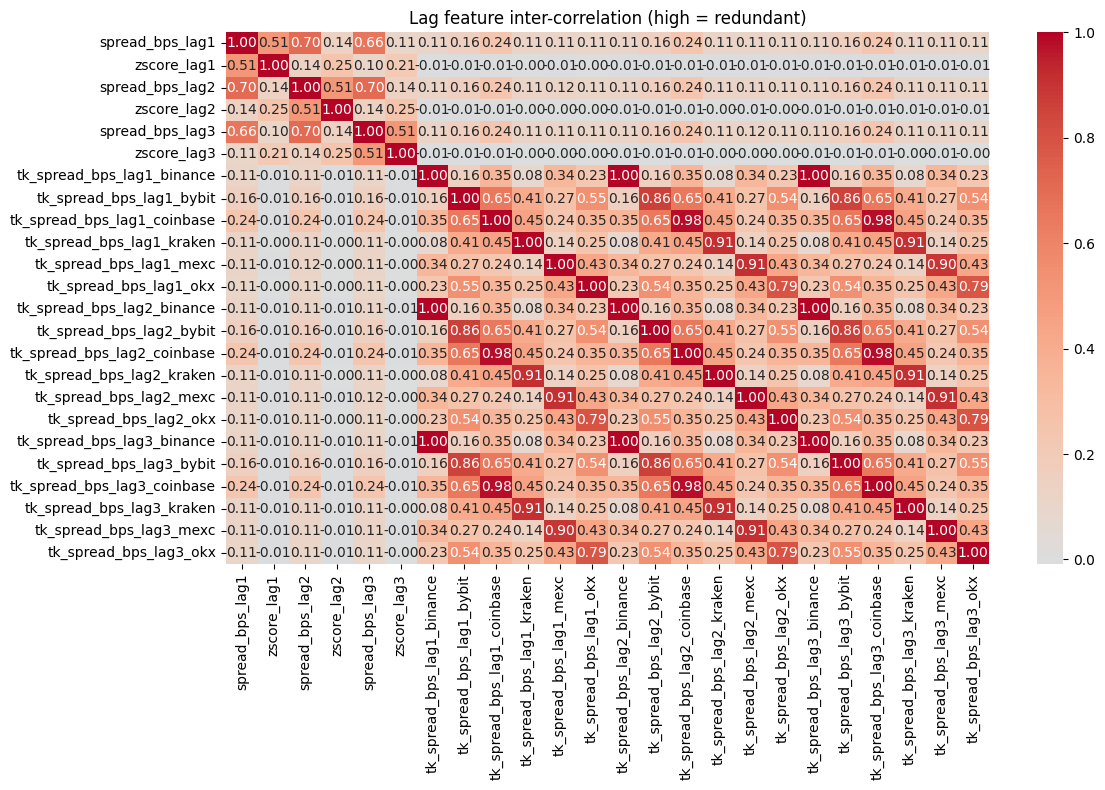

In [12]:
# ── Correlation heatmap between lag features (detect redundancy) ─────────────
import matplotlib.pyplot as plt
import seaborn as sns

# just zscore and spread_bps lags — the core features
core_lags = [c for c in feature_cols if any(x in c for x in ["zscore_lag", "spread_bps_lag"])]
corr_matrix = df_train[core_lags].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Lag feature inter-correlation (high = redundant)")
plt.tight_layout()
plt.show()

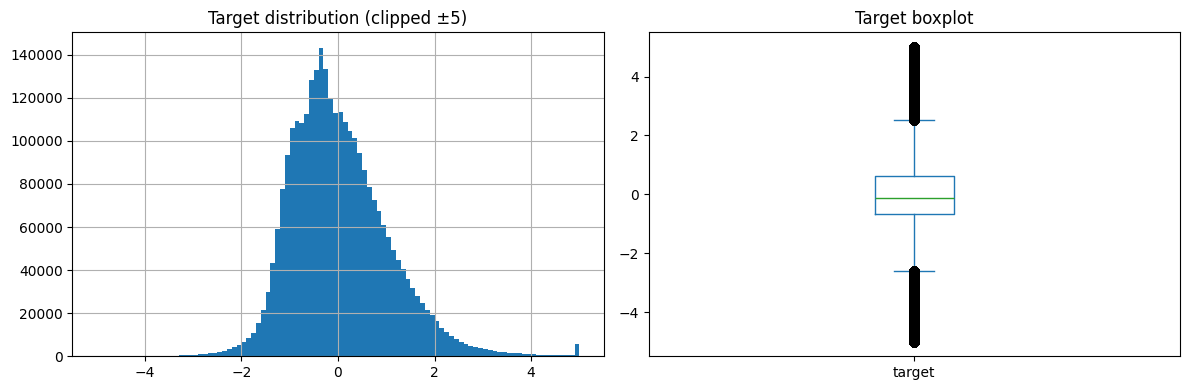

Target stats:
count    2.952122e+06
mean     3.038113e-02
std      1.044449e+00
min     -8.872326e+00
25%     -6.804712e-01
50%     -1.088390e-01
75%      6.070099e-01
max      1.715323e+01
Name: target, dtype: float64
% outside ±2σ : 4.69%
% outside ±3σ : 1.14%


In [13]:
# ── Target distribution check ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train["target"].clip(-5, 5).hist(bins=100, ax=axes[0])
axes[0].set_title("Target distribution (clipped ±5)")

df_train["target"].clip(-5, 5).plot(kind="box", ax=axes[1])
axes[1].set_title("Target boxplot")
plt.tight_layout()
plt.show()

print(f"Target stats:\n{df_train['target'].describe()}")
print(f"% outside ±2σ : {(df_train['target'].abs() > 2).mean():.2%}")
print(f"% outside ±3σ : {(df_train['target'].abs() > 3).mean():.2%}")

# 8.5.2 - Chop chop

try removing unnecessary cols, log transforming cols, winsorizing other cols

In [14]:
# ── 1. DROP: all-null or all-zero columns ────────────────────────────────────
drop_null   = report_df[report_df["null_pct"] > 0.4]["feature"].tolist() # 0.5
drop_zero   = report_df[report_df["near_zero"] > 0.4]["feature"].tolist() # 0.5

# ── 2. DROP: tk_mid (raw price level — not useful for spread prediction) ─────
#drop_mid    = [c for c in df_train.columns if "tk_mid" in c]

# ── 3. DROP: weak linear correlation AND low importance (volume/ratio cols) ──
drop_weak   = report_df[report_df["corr_target"].abs() < 0.005]["feature"].tolist() # 0.005

all_drops = list(set(drop_null + drop_zero + drop_weak)) # list(set(drop_null + drop_zero + drop_mid + drop_weak))
print(f"Dropping {len(all_drops)} columns")

for df in [df_train, df_test, df_val]:
    df.drop(columns=[c for c in all_drops if c in df.columns], inplace=True)

# ── 4. LOG TRANSFORM: volume and buy_sell_ratio (skew > 2, kurtosis > 10) ───
# signed log to handle zeros and negatives
def signed_log1p(s):
    return np.sign(s) * np.log1p(np.abs(s))

log_patterns = ["tk_bid_volume", "tk_ask_volume", "tr_total_volume", "tr_buy_sell_ratio"]
log_cols = [c for c in df_train.columns
            if any(p in c for p in log_patterns)]
print(f"Log-transforming {len(log_cols)} columns")

for df in [df_train, df_test, df_val]:
    for col in [c for c in log_cols if c in df.columns]:
        df[col] = signed_log1p(df[col])

# ── 5. WINSORIZE: spread_bps lags and tk_spread_bps (kurtosis 16-18) ─────────
from scipy.stats.mstats import winsorize

winsor_patterns = ["spread_bps_lag", "tk_spread_bps"]
winsor_cols = [c for c in df_train.columns
               if any(p in c for p in winsor_patterns)]
print(f"Winsorizing {len(winsor_cols)} columns")

for df in [df_train, df_test, df_val]:
    for col in [c for c in winsor_cols if c in df.columns]:
        df[col] = winsorize(df[col].fillna(df[col].median()), limits=[0.01, 0.01])

# ── 6. CLIP TARGET at ±3σ ────────────────────────────────────────────────────
#for df in [df_train, df_test, df_val]:
    #df["target"] = df["target"].clip(-3, 3)

print("\nDone. Remaining shape:", df_train.shape)
print(df_train.describe().T[["mean","std","min","max"]].to_string())

Dropping 88 columns
Log-transforming 0 columns
Winsorizing 21 columns

Done. Remaining shape: (3013218, 68)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask'

                                      mean           std       min           max
snapshot_idx                   1669.611429   1083.360413  1.000000   3909.000000
spread_bps                        6.772762      6.830948  0.000000    172.740005
zscore                            0.030381      1.044449 -8.872326     17.153229
target                            0.030381      1.044449 -8.872326     17.153229
spread_bps_lag1                   6.691528      6.420986  0.000000     32.000000
zscore_lag1                       0.030398      1.044472 -8.872326     17.153229
spread_bps_lag2                   6.690413      6.419502  0.000000     31.990000
zscore_lag2                       0.030350      1.044438 -8.872326     17.153229
spread_bps_lag3                   6.689408      6.418043  0.000000     31.990000
zscore_lag3                       0.030292      1.044423 -8.872326     17.153229
tk_mid_lag1_binance            2877.647949  12885.983398  0.000000  67274.007812
tk_mid_lag1_bybit           

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


# 8.5.3 - Feature engineer

In [15]:
def add_cross_exchange_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    exchanges = ["binance", "bybit", "okx", "coinbase", "kraken"]

    # ── 1. Mid-price dispersion across exchanges at each snapshot ─────────────
    # How wide is the price spread across ALL venues right now?
    mid_cols = [f"tk_mid_lag1_{ex}" for ex in exchanges if f"tk_mid_lag1_{ex}" in df.columns]
    if mid_cols:
        df["cross_mid_std"]   = df[mid_cols].std(axis=1)   # overall dispersion
        df["cross_mid_range"] = df[mid_cols].max(axis=1) - df[mid_cols].min(axis=1)  # max gap

    # ── 2. Which exchange is cheapest/most expensive right now ────────────────
    # Rank each exchange's mid price within each row (0=cheapest, 1=most expensive)
    if mid_cols:
        ranks = df[mid_cols].rank(axis=1, pct=True)
        for col, ex in zip(mid_cols, exchanges):
            df[f"price_rank_{ex}"] = ranks[col]

    # ── 3. Bid-ask spread dispersion — where is liquidity tightest? ───────────
    ba_cols = [f"tk_spread_bps_lag1_{ex}" for ex in exchanges
               if f"tk_spread_bps_lag1_{ex}" in df.columns]
    if ba_cols:
        df["cross_ba_std"] = df[ba_cols].std(axis=1)
        df["tightest_ba"]  = df[ba_cols].min(axis=1)
        df["widest_ba"]    = df[ba_cols].max(axis=1)
        df["ba_range"]     = df["widest_ba"] - df["tightest_ba"]

    # ── 4. Order book imbalance divergence ────────────────────────────────────
    # If binance OB is bid-heavy but bybit is ask-heavy, that's a directional signal
    ob_cols = [f"ob_imbalance_lag1_{ex}" for ex in exchanges
               if f"ob_imbalance_lag1_{ex}" in df.columns]
    if ob_cols:
        df["cross_ob_std"]   = df[ob_cols].std(axis=1)
        df["cross_ob_range"] = df[ob_cols].max(axis=1) - df[ob_cols].min(axis=1)
        # net imbalance across all venues — aggregate buy/sell pressure
        df["net_ob_pressure"] = df[ob_cols].mean(axis=1)

    # ── 5. Trade flow divergence ──────────────────────────────────────────────
    # If one exchange has buy pressure and another has sell pressure = arb signal
    flow_cols = [f"tr_buy_sell_ratio_lag1_{ex}" for ex in exchanges
                 if f"tr_buy_sell_ratio_lag1_{ex}" in df.columns]
    if flow_cols:
        df["cross_flow_std"]  = df[flow_cols].std(axis=1)
        df["net_flow_signal"] = df[flow_cols].mean(axis=1)
        df["flow_divergence"] = df[flow_cols].max(axis=1) - df[flow_cols].min(axis=1)

    # ── 6. Spread momentum — is the spread widening or narrowing? ─────────────
    # lag1 - lag3 gives direction of spread movement
    for lag_a, lag_b in [(1, 3), (1, 5)]:
        if f"spread_bps_lag{lag_a}" in df.columns and f"spread_bps_lag{lag_b}" in df.columns:
            df[f"spread_momentum_{lag_a}_{lag_b}"] = (
                df[f"spread_bps_lag{lag_a}"] - df[f"spread_bps_lag{lag_b}"]
            )
        if f"zscore_lag{lag_a}" in df.columns and f"zscore_lag{lag_b}" in df.columns:
            df[f"zscore_momentum_{lag_a}_{lag_b}"] = (
                df[f"zscore_lag{lag_a}"] - df[f"zscore_lag{lag_b}"]
            )

    # ── 7. Z-score acceleration (second derivative) ───────────────────────────
    if all(f"zscore_lag{l}" in df.columns for l in [1, 2, 3]):
        df["zscore_accel"] = (
            df["zscore_lag1"] - 2 * df["zscore_lag2"] + df["zscore_lag3"]
        )

    print(f"Added {len([c for c in df.columns if c not in df.columns])} cross-exchange features")
    print(f"New shape: {df.shape}")
    return df

df_train = add_cross_exchange_features(df_train)
df_test  = add_cross_exchange_features(df_test)
df_val   = add_cross_exchange_features(df_val)

Added 0 cross-exchange features
New shape: (3013218, 85)
Added 0 cross-exchange features
New shape: (788193, 85)
Added 0 cross-exchange features
New shape: (0, 0)


## 9. Prepare LightGBM Datasets
- Drops rows where `target` is NaN (first `HORIZON` rows of each group, and z-score warmup rows)
- `coin` and `pair` are encoded as LightGBM native categoricals — no one-hot needed
- Test/val columns are re-aligned to train's column set (some exchanges may be absent in shorter splits)

In [16]:
ID_COLS = {"snapshot_idx", "exchange_a", "exchange_b", "spread_bps", "zscore", "target", "p1", "p2"}

def prepare_dataset(df: pd.DataFrame, reference_cols=None):
    df = df.dropna(subset=["target"]).copy()

    cat_cols = [c for c in ["coin", "pair"] if c in df.columns]
    for c in cat_cols:
        df[c] = df[c].astype("category")

    feat_cols = [c for c in df.columns if c not in ID_COLS]
    X = df[feat_cols].copy()
    y = df["target"].values

    if reference_cols is not None:
        X = X.reindex(columns=reference_cols)
        for c in cat_cols:
            if c in X.columns:
                X[c] = X[c].astype("category")

    return X, y, feat_cols, cat_cols

X_train, y_train, feat_cols, cat_cols = prepare_dataset(df_train)
X_test,  y_test,  _,         _        = prepare_dataset(df_test,  reference_cols=X_train.columns)
#X_val,   y_val,   _,         _        = prepare_dataset(df_val,   reference_cols=X_train.columns)

print(f"Train : {X_train.shape}  |  target mean={y_train.mean():.3f}  std={y_train.std():.3f}")
print(f"Test  : {X_test.shape}")
#print(f"Val   : {X_val.shape}")

Train : (2952122, 81)  |  target mean=0.030  std=1.046
Test  : (747483, 81)


## 10. Train
Early stopping is evaluated on the **test** split.  
Once architecture is locked, consider using a time-based slice of train for early stopping instead, so test stays fully held-out.

In [17]:
dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols, free_raw_data=False)
dtest  = lgb.Dataset(X_test,  label=y_test,  categorical_feature=cat_cols,
                     reference=dtrain, free_raw_data=False)

model = lgb.train(
    LGBM_PARAMS,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    valid_sets=[dtrain, dtest],
    valid_names=["train", "test"],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING, verbose=True),
        lgb.log_evaluation(100),
    ],
)
print(f"\nBest iteration: {model.best_iteration}")

Training until validation scores don't improve for 250 rounds
[100]	train's rmse: 0.981427	train's l1: 0.73193	test's rmse: 0.98207	test's l1: 0.742274
[200]	train's rmse: 0.969956	train's l1: 0.723894	test's rmse: 0.983181	test's l1: 0.743311
[300]	train's rmse: 0.961009	train's l1: 0.717407	test's rmse: 0.984828	test's l1: 0.744514
Early stopping, best iteration is:
[77]	train's rmse: 0.984744	train's l1: 0.734303	test's rmse: 0.98186	test's l1: 0.742147

Best iteration: 77


## 11. Evaluate
`dir_acc` (directional accuracy) is the most operationally meaningful metric —  
it tells you how often the model correctly predicts whether the spread is above or below its rolling mean.

In [18]:
def evaluate(model, X, y, label):
    preds   = model.predict(X, num_iteration=model.best_iteration)
    mae     = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2      = r2_score(y, preds)
    dir_acc = np.mean(np.sign(preds) == np.sign(y))
    print(f"{label:20s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  DirAcc={dir_acc:.3%}")
    return {"label": label, "mae": mae, "rmse": rmse, "r2": r2, "dir_acc": dir_acc}

results = []
results.append(evaluate(model, X_train, y_train, "train"))
results.append(evaluate(model, X_test,  y_test,  "test"))
#if len(y_val) > 0:
#    results.append(evaluate(model, X_val, y_val, "val (partial)"))

results_df = pd.DataFrame(results)
results_df

train                 MAE=0.7343  RMSE=0.9847  R²=0.1135  DirAcc=61.137%
test                  MAE=0.7421  RMSE=0.9819  R²=0.1131  DirAcc=61.428%


,label,mae,rmse,r2,dir_acc
0,train,0.734303,0.984744,0.113458,0.611371
1,test,0.742147,0.981860,0.113144,0.614278


## 12. Feature Importance

In [19]:
imp_df = pd.DataFrame({
    "feature":    model.feature_name(),
    "importance": model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(imp_df.head(30).to_string())

                        feature     importance
0                   zscore_lag1  496762.858874
1                   zscore_lag2  310384.970572
2                   zscore_lag3  304418.786688
3                          coin  101822.344123
4           zscore_momentum_1_3   86099.348862
5                          pair   69476.178226
6                  zscore_accel   65337.214271
7               spread_bps_lag2   51469.006353
8               spread_bps_lag1   38529.740140
9               spread_bps_lag3   19700.993171
10                cross_mid_std   14129.381288
11              cross_mid_range   13435.241531
12    tk_spread_bps_lag2_kraken   11504.640691
13      tk_spread_bps_lag2_mexc   10668.742600
14      tk_spread_bps_lag1_mexc   10643.672312
15    tk_spread_bps_lag3_kraken   10553.677071
16    tk_spread_bps_lag1_kraken   10115.084517
17          spread_momentum_1_3   10041.037012
18  tk_spread_bps_lag2_coinbase    9778.634388
19       tk_spread_bps_lag3_okx    9693.453261
20     tk_spr

## 13. Save Outputs

In [20]:
model.save_model(str(OUTPUT_DIR / "statarb_lgbm.txt"))
imp_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "eval_results.csv", index=False)

print(f"Saved to {OUTPUT_DIR}/")
print("  statarb_lgbm.txt")
print("  feature_importance.csv")
print("  eval_results.csv")

Saved to outputs/
  statarb_lgbm.txt
  feature_importance.csv
  eval_results.csv
